## Participants

In this study, participants were recruited among the population of students, professors, and researchers of the University of Udine.
A total of 53 people (40 males, 13 females) participated,
ranging in age from 20 to 45 years with mean of 25.1
and standard deviation of 4.1. All participants have been
subjected to the Handedness Questionnaire [37] in order
to calculate their Laterality Index (LI); fifty of them were
mainly right-handed, the other three left-handed.
The right hand span of each subject was measured before
the experiment and a value of 20.9 ± 1.8 cm was found. Six
participants had a previous practice with flight simulator
joysticks, five of them had experience in the driving of an
excavator by means of joysticks and forty three subjects
had practice with video game console before. None of the
subjects involved in the experiment had a mobility disorder
of upper limbs, twenty six of them were wearing glasses.
The University of Trieste Ethics Committee approved the
experimental protocol and each participant gave informed
consent prior to starting the tests.

In [72]:
manual_cols = [
    "timestamp",
    "operator_id",
    "gender",
    "age",
    "job",
    "job_other",
    "experience",
    "product",
    "task_clarity",
    "sequence_intuitive",
    "perceived_difficulty",
    "perceived_time",
    "perceived_difficulty_what",
    "perceived_effort",
    "comfortable",
    "fatigue",
    "fatigue_when",
    "assured",
    "danger",
    "danger_when",
    "efficency",
    "instruments",
    "fluidity",
    "instruments_what",
    "rating",
    "pros",
    "cons",
    "comments_overall",
]

In [73]:
robot_cols = [
    "timestamp",
    "operator_id",
    "gender",
    "age",
    "job",
    "job_other",
    "experience",
    "product",
    "task_clarity",
    "robot_facilitated",
    "robot_natural_interaction",
    "perceived_time",
    "robot_obstacle",
    "robot_obstacle_when",
    "robot_safe",
    "robot_velocity",
    "robot_collision",
    "robot_collision_when",
    "safety_effective",
    "hci_simple",
    "robot_trajectory",
    "system_feedback",
    "comments_system",
    "reduced_robot_downtime",
    "robot_timely",
    "interaction_fluidity",
    "rating",
    "pros",
    "cons",
    "comments_overall",
]

In [74]:
import pandas as pd

manual = "data/Manual assembly.csv"
robot = "data/Robot-assisted assembly.csv"

In [75]:
df_m = pd.read_csv(manual)
df_m.columns = manual_cols
len(df_m["operator_id"].unique())

44

In [76]:
df_r = pd.read_csv(robot)
df_r.columns = robot_cols
len(df_r["operator_id"].unique())

40

In [77]:
df_m.to_csv("data/manual.csv", index=None)
df_r.to_csv("data/robot.csv", index=None)

In [127]:
df_r_time_1 = pd.read_csv("data/robot_time_car.csv")
df_r_time_1 = df_r_time_1.groupby(["id", "test"]).last().reset_index()
df_r_time_1["application"] = "car"

df_r_time_2 = pd.read_csv("data/robot_time_lego.csv")
df_r_time_2 = df_r_time_2.groupby(["id", "test"]).last().reset_index()
df_r_time_2["application"] = "lego"

df_r_time = pd.concat((df_r_time_1, df_r_time_2))

df_r_time["time"] = df_r_time["time"] + df_r_time["timestamp"]
df_r_time.drop(columns=["test", "model", "timestamp", "agent", "component"], inplace=True)
df_r_time.to_csv("data/robot_time.csv", index=None)

In [249]:
translation_dicts = {
    # Gender mappings
    # "gender": {
    #     "M": "Male", 
    #     "F": "Female"
    # },

    # Age groups mappings
    "age": {
        ">= 18 e < 25": "A", 
        ">= 25 e < 30": "B", 
        ">= 30 e < 40": "C", 
        ">= 40 e < 50": "D", 
        ">= 50": "E"
    },

    # Job mappings
    "job": {
        "Studente": "Student", 
        "Ricercatore": "Researcher", 
        "Ingegnere / Progettista": "Engineer", 
        "Altro": "Other",
        "Studente / Student": "Student",
        "Ricercatore / Researcher": "Researcher",
    },

    # Experience level mappings
    "experience": {
        "Nessuna": "0_None", 
        "Base (≤ 1 anno)": "1_Basic", 
        "Intermedia (1–3 anni)": "2_Intermediate", 
        "Avanzata (> 3 anni)": "3_Advanced",
        "Nessuna": "None",
        "Nessuna / None": "None",
        "Base (≤ 1 anno)": "1_Basic", 
        "Base (≤ 1 anno) / Basic (≤ 1 year)": "1_Basic", 
        "Intermedia (1–3 anni)": "2_Intermediate", 
        "Avanzata (> 3 anni)": "3_Advanced",
    },

    # Product mappings (Already mostly English, but included for consistency)
    "product": {
        "LEGO Duplo": "lego", 
        "Racing Car Toy": "car"
    },

    # Perceived time mappings
    "perceived_time": {
        "Adeguato": "2_Adequate", 
        "Troppo lungo": "3_Too long", 
        "Troppo breve": "1_Too short", 
        "Non saprei": "0_I don't know",
        "Adeguato": "2_Adequate",
        "Adeguato / Adequate": "2_Adequate",
        "Troppo lungo": "3_Too long",
        "Troppo lungo / Too long": "3_Too long"
    },

    "robot_velocity": {
        "Adeguato": "2_Adequate", 
        "Adeguati": "2_Adequate", 
        "Adeguati / Adequate": "2_Adequate", 
        "Troppo lungo": "3_Too long", 
        "Troppo lenti": "3_Too long", 
        "Troppo lenti / Too slow": "3_Too long", 
        "Troppo breve": "1_Too short", 
        "Troppo veloci": "1_Too short", 
        "Non saprei": "0_I don't know"
    },

    # Fatigue mappings
    "fatigue": {
        "No": "No", 
        "Sì": "Yes"
    },
    "robot_obstacle": {
        "No": "No", 
        "Sì": "Yes"
    },
    "robot_collision": {
        "Mai": "Never",
        "Mai / Never": "Never",
        "A volte": "Sometimes"
    },
    "system_feedback": {
        "Sì": "Yes",
        "Sì / Yes": "Yes",
        "No": "No"
    },
    "reduced_robot_downtime": {
        "Sì, leggermente": "Yes, slightly",
        "Sì, leggermente / Yes, slightly": "Yes, slightly",
        "Sì, significativamente": "Yes, significantly",
        "Non saprei": "I don't know",
        "Non saprei / I would not know": "I don't know",
        "No": "No"
    },

    # Danger mappings (Consistently answered as "No, never" where present)
    "danger": {
        "No, mai": "No"
    }
}

In [250]:
df_m = pd.read_csv("data/manual.csv")
df_m.replace(translation_dicts, inplace=True)

df_m_time = pd.read_csv("data/manual_time.csv")

# check if (operator_id, product) are the same

set1 = {tuple(data) for _, data in df_m[["operator_id", "product"]].iterrows()}
set2 = {tuple(data) for _, data in df_m_time[["id", "application"]].iterrows()}
print(set1==set2)

df_m["exp_id"] = df_m["product"]+"_"+df_m["operator_id"].astype(str)
df_m_time["exp_id"] = df_m_time["application"]+"_"+df_m_time["id"].astype(str)

df_m.set_index("exp_id", inplace=True)
df_m_time.set_index("exp_id", inplace=True)

df_m["time"] = df_m_time.time
df_m.reset_index().to_csv("data/manual_with_time.csv", index=None)

True


In [251]:
df_r = pd.read_csv("data/robot.csv")
df_r.replace(translation_dicts, inplace=True)

df_r_time = pd.read_csv("data/robot_time.csv")

# check if (operator_id, product) are the same

set1 = {tuple(data) for _, data in df_r[["operator_id", "product"]].iterrows()}
set2 = {tuple(data) for _, data in df_r_time[["id", "application"]].iterrows()}
print(set1==set2)

df_r["exp_id"] = df_r["product"]+"_"+df_r["operator_id"].astype(str)
df_r_time["exp_id"] = df_r_time["application"]+"_"+df_r_time["id"].astype(str)

df_r.set_index("exp_id", inplace=True)
df_r_time.set_index("exp_id", inplace=True)

df_r["time"] = df_r_time.time
df_r.reset_index().to_csv("data/robot_with_time.csv", index=None)

True


In [252]:
df_m = pd.read_csv("data/manual_with_time.csv")
df_r = pd.read_csv("data/robot_with_time.csv")
df_m["kind"] = "manual"
df_r["kind"] = "robot"
df = pd.concat((df_m, df_r))
df

,exp_id,timestamp,operator_id,gender,age,job,job_other,experience,product,task_clarity,...,robot_collision,robot_collision_when,safety_effective,hci_simple,robot_trajectory,system_feedback,comments_system,reduced_robot_downtime,robot_timely,interaction_fluidity
0,lego_1,12/2/2025 19:01:14,1,M,C,Researcher,NaN,None,lego,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,car_2,12/2/2025 19:13:22,2,M,C,Other,AVVOCATO,1_Basic,car,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lego_3,12/15/2025 18:01:21,3,M,B,Student,NaN,3_Advanced,lego,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,car_4,12/15/2025 22:30:53,4,M,A,Student,NaN,None,car,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,lego_5,12/16/2025 15:51:32,5,M,C,Other,Sviluppatore software in ambito AI,1_Basic,lego,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,car_55,3/19/2026 15:18:18,55,M,A,Student,NaN,1_Basic,car,5,...,Never,NaN,3.0,5.0,5.0,Yes,NaN,"Yes, slightly",5.0,3.0
41,car_56,3/22/2026 23:17:17,56,M,A,Student,NaN,1_Basic,car,5,...,Never,NaN,5.0,5.0,5.0,Yes,NaN,"Yes, slightly",4.0,4.0
42,car_58,3/25/2026 13:22:40,58,M,A,Student,NaN,None,car,5,...,Never,NaN,3.0,4.0,4.0,Yes,NaN,I don't know,3.0,1.0
43,car_59,4/10/2026 14:23:32,59,M,C,Researcher,NaN,1_Basic,car,5,...,Never,NaN,5.0,5.0,5.0,Yes,NaN,"Yes, slightly",5.0,5.0


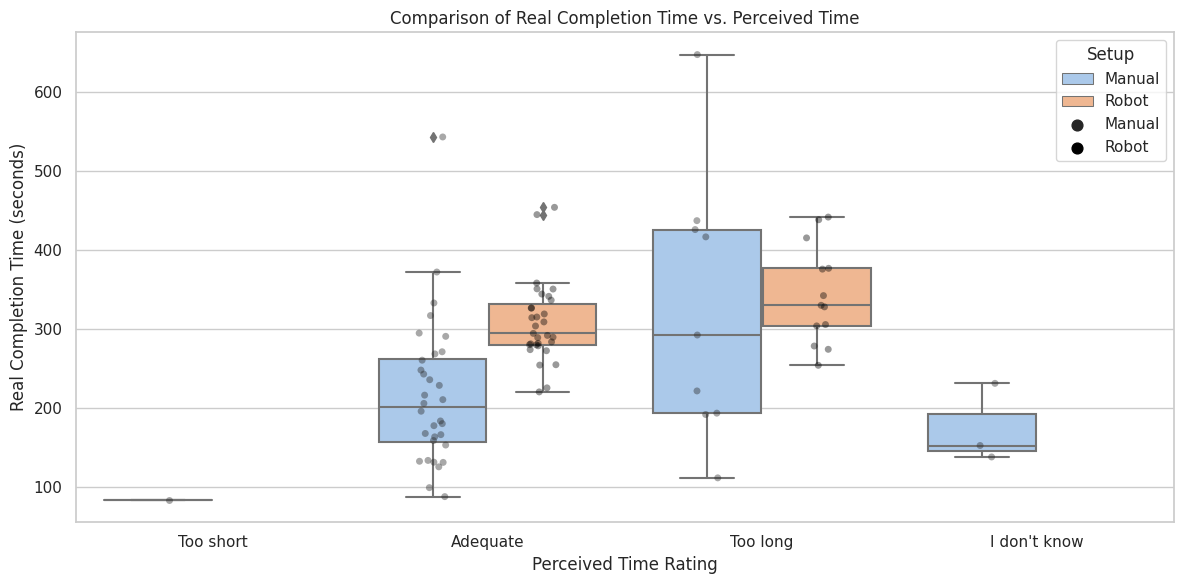

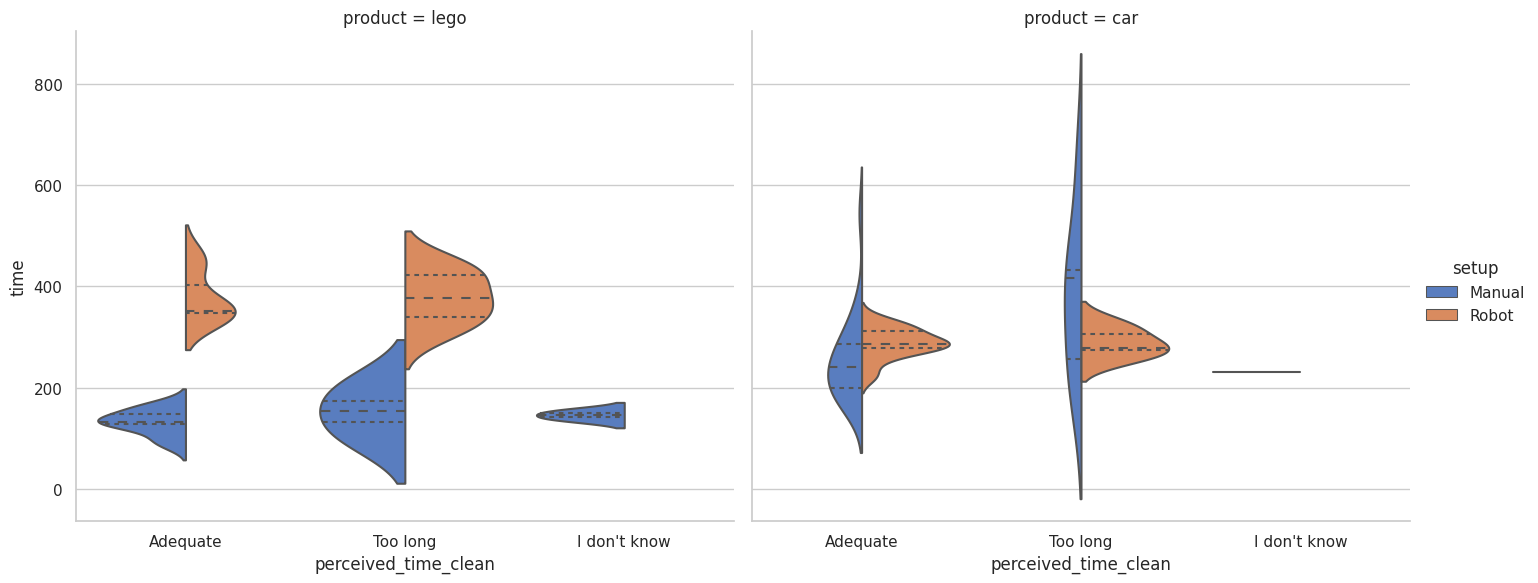

In [253]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets that include the 'time' and 'perceived_time' variables
df_manual = pd.read_csv('data/manual_with_time.csv')
df_robot = pd.read_csv('data/robot_with_time.csv')

# Assign a setup column to distinguish the two datasets
df_manual['setup'] = 'Manual'
df_robot['setup'] = 'Robot'

# Combine into a single DataFrame
df_combined = pd.concat([df_manual, df_robot], ignore_index=True)

# Clean the 'perceived_time' column
# The data contains prefixes like "2_Adequate", "1_Too long", "0_I don't know", "1_Too short"
def clean_perceived_time_label(val):
    if pd.isna(val):
        return val
    val_str = str(val)
    if '_' in val_str:
        return val_str.split('_', 1)[1]
    return val_str

df_combined['perceived_time_clean'] = df_combined['perceived_time'].apply(clean_perceived_time_label)

# Set the visual style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Plot 1: Boxplot of Real Time vs. Perceived Time by Setup
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_combined, 
    x='perceived_time_clean', 
    y='time', 
    hue='setup',
    order=['Too short', 'Adequate', 'Too long', "I don't know"],
    palette='pastel'
)
# Adding a strip plot on top to see individual data points
sns.stripplot(
    data=df_combined, 
    x='perceived_time_clean', 
    y='time', 
    hue='setup',
    order=['Too short', 'Adequate', 'Too long', "I don't know"],
    dodge=True, 
    color='black', 
    alpha=0.4, 
    # legend=False
)

plt.title('Comparison of Real Completion Time vs. Perceived Time')
plt.xlabel('Perceived Time Rating')
plt.ylabel('Real Completion Time (seconds)')
plt.legend(title='Setup')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Plot 2: Real vs. Perceived Time Faceted by Product (LEGO vs. Car)
# ---------------------------------------------------------
g = sns.catplot(
    data=df_combined, 
    x='perceived_time_clean', 
    y='time', 
    hue='setup', 
    col='product', 
    kind='violin',
    split=True,
    inner='quartile',
    order=['Adequate', 'Too long', "I don't know"], # Excluded "Too short" to keep it cleaner if data is sparse
    palette='muted',
    height=6, 
    aspect=1.2
)

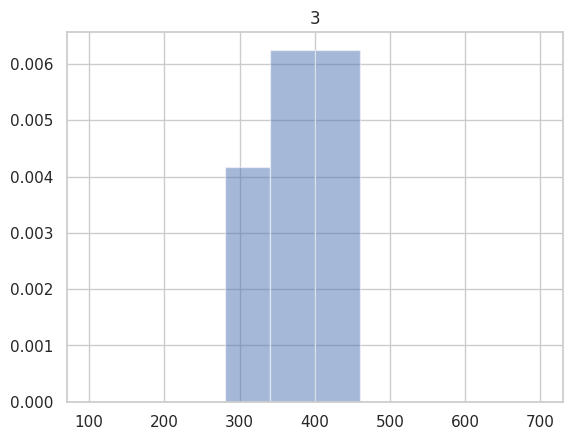

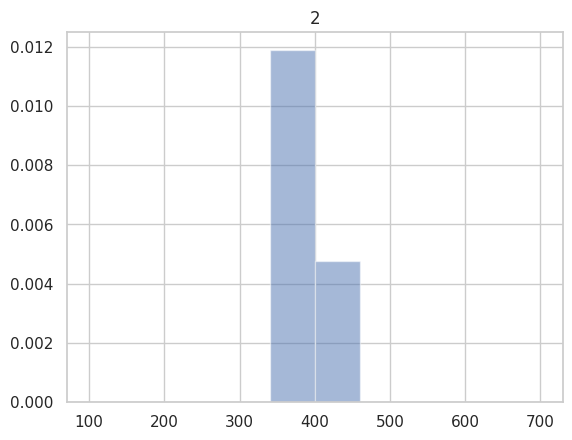

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


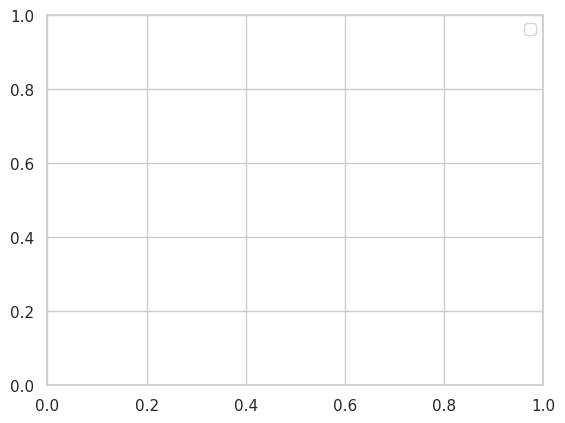

In [298]:
car_manual = (df_combined["product"]=="lego")&(df_combined["setup"]=="Robot")


perc = df_combined.int_perceived_time[car_manual]
time = df_combined.time[car_manual]


for p in sorted(perc.unique())[::-1]:
    plt.hist(time[perc==p], label=p, alpha=.5, range=(100,700), density=True)
    plt.title(p)
    plt.show()
plt.legend()

In [258]:
df_combined.perceived_time.unique()

array(['2_Adequate', '3_Too long', "0_I don't know", '1_Too short', nan],
      dtype=object)

In [195]:
df_combined.columns

Index(['exp_id', 'timestamp', 'operator_id', 'gender', 'age', 'job',
       'job_other', 'experience', 'product', 'task_clarity',
       'sequence_intuitive', 'perceived_difficulty', 'perceived_time',
       'perceived_difficulty_what', 'perceived_effort', 'comfortable',
       'fatigue', 'fatigue_when', 'assured', 'danger', 'danger_when',
       'efficency', 'instruments', 'fluidity', 'instruments_what', 'rating',
       'pros', 'cons', 'comments_overall', 'time', 'setup',
       'robot_facilitated', 'robot_natural_interaction', 'robot_obstacle',
       'robot_obstacle_when', 'robot_safe', 'robot_velocity',
       'robot_collision', 'robot_collision_when', 'safety_effective',
       'hci_simple', 'robot_trajectory', 'system_feedback', 'comments_system',
       'reduced_robot_downtime', 'robot_timely', 'interaction_fluidity',
       'perceived_time_clean'],
      dtype='object')

In [222]:
df_combined.danger.unique()

array(['No', nan], dtype=object)

In [255]:
def numericalize_cols(df):
    df["int_gender"] = [0 if x=="M" else 1 for x in df.gender.tolist()]
    df["int_age"] = df.age.replace({"A":0, "B":1, "C":2, "D":3, "E":4})
    df["int_job_stu"] = (df.job == "Student").astype(int)
    df["int_job_eng"] = (df.job == "Engineer").astype(int)
    df["int_job_res"] = (df.job == "Researcher").astype(int)
    df["int_job_oth"] = (df.job == "Other").astype(int)
    df["int_experience"] = df.experience.replace("None", "0_none").apply(lambda x: int(x.split("_")[0]))
    df["int_perceived_time"] = df["perceived_time"].fillna("0_").apply(lambda x: int(x.split("_")[0]))
    df["int_fatigue"] = (df.fatigue == "Yes").astype(int)
    df["int_danger"] = (df.danger == "Yes").astype(int)
    df["int_robot_obstacle"] = (df.robot_obstacle == "Yes").astype(int)
    df["int_robot_velocity"] = df["robot_velocity"].fillna("0_").apply(lambda x: int(x.split("_")[0]))
    df["int_robot_collision"] = (df.robot_collision == "Sometimes").astype(int)
    df["int_system_feedback"] = (df.system_feedback == "Yes").astype(int)
    df["int_reduced_robot_downtime"] = df.reduced_robot_downtime.replace({
        'Yes, slightly':1, 'Yes, significantly':2, "I don't know":0, 'No':0,
    })
    
    return df
numericalize_cols(df_combined)

,exp_id,timestamp,operator_id,gender,age,job,job_other,experience,product,task_clarity,...,int_job_oth,int_experience,int_perceived_time,int_fatigue,int_danger,int_robot_obstacle,int_robot_velocity,int_robot_collision,int_system_feedback,int_reduced_robot_downtime
0,lego_1,12/2/2025 19:01:14,1,M,C,Researcher,NaN,None,lego,4,...,0,0,2,0,0,0,0,0,0,NaN
1,car_2,12/2/2025 19:13:22,2,M,C,Other,AVVOCATO,1_Basic,car,4,...,1,1,3,0,0,0,0,0,0,NaN
2,lego_3,12/15/2025 18:01:21,3,M,B,Student,NaN,3_Advanced,lego,5,...,0,3,3,0,0,0,0,0,0,NaN
3,car_4,12/15/2025 22:30:53,4,M,A,Student,NaN,None,car,5,...,0,0,2,0,0,0,0,0,0,NaN
4,lego_5,12/16/2025 15:51:32,5,M,C,Other,Sviluppatore software in ambito AI,1_Basic,lego,5,...,1,1,2,0,0,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,car_55,3/19/2026 15:18:18,55,M,A,Student,NaN,1_Basic,car,5,...,0,1,3,0,0,0,3,0,1,1.0
86,car_56,3/22/2026 23:17:17,56,M,A,Student,NaN,1_Basic,car,5,...,0,1,3,0,0,0,3,0,1,1.0
87,car_58,3/25/2026 13:22:40,58,M,A,Student,NaN,None,car,5,...,0,0,2,0,0,0,2,0,1,0.0
88,car_59,4/10/2026 14:23:32,59,M,C,Researcher,NaN,1_Basic,car,5,...,0,1,2,0,0,0,2,0,1,1.0


In [256]:
num_columns = [
    "int_gender",
    "int_age",
    "int_job_stu",
    "int_job_eng",
    "int_job_res",
    "int_job_oth",
    "int_experience",
    "task_clarity", "sequence_intuitive", 'perceived_difficulty',
    'int_perceived_time',
    'perceived_effort', 'comfortable',
    'int_fatigue',
    'assured',
    'int_danger',
    'efficency', 'instruments', 'fluidity', 'rating', 'time',
    'robot_facilitated', 'robot_natural_interaction',
    'int_robot_obstacle',
    'robot_safe', 'int_robot_velocity', 'int_robot_collision',
    'safety_effective',
    'hci_simple', 'robot_trajectory', 'int_system_feedback',
    'int_reduced_robot_downtime', 'robot_timely', 'interaction_fluidity'
]
# corr = df_combined[(df_combined["product"]=="car")&(df_combined["setup"]=="Manual")][num_columns].corr()
# corr = df_combined[(df_combined["product"]=="lego")&(df_combined["setup"]=="Manual")][num_columns].corr()
corr = df_combined[(df_combined["product"]=="car")&(df_combined["setup"]=="Robot")][num_columns].corr()
# corr = df_combined[(df_combined["product"]=="lego")&(df_combined["setup"]=="Robot")][num_columns].corr()
# print(corr.index)
# print(len(num_columns))
# print(corr.shape)
corr.style.background_gradient(cmap='coolwarm')
# display(corr)


/home/bportelli/venv8/lib/python3.8/site-packages/pandas/io/formats/style.py:3554: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/home/bportelli/venv8/lib/python3.8/site-packages/pandas/io/formats/style.py:3555: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,int_gender,int_age,int_job_stu,int_job_eng,int_job_res,int_job_oth,int_experience,task_clarity,sequence_intuitive,perceived_difficulty,int_perceived_time,perceived_effort,comfortable,int_fatigue,assured,int_danger,efficency,instruments,fluidity,rating,time,robot_facilitated,robot_natural_interaction,int_robot_obstacle,robot_safe,int_robot_velocity,int_robot_collision,safety_effective,hci_simple,robot_trajectory,int_system_feedback,int_reduced_robot_downtime,robot_timely,interaction_fluidity
int_gender,1.000000,0.454707,-0.381181,nan,0.235702,0.259259,-0.012887,0.089087,nan,nan,0.144430,nan,nan,nan,nan,nan,nan,nan,nan,0.016901,-0.124305,0.133870,0.066336,-0.089087,0.015731,-0.061898,0.050252,0.101080,0.126357,0.183892,0.089087,0.175682,0.062313,0.122536
int_age,0.454707,1.000000,-0.661643,nan,0.329988,0.574367,-0.308112,-0.124724,nan,nan,-0.413297,nan,nan,nan,nan,nan,nan,nan,nan,0.203851,-0.109792,0.360424,0.317906,-0.019188,0.088095,-0.213314,-0.043295,0.293913,0.085535,0.039608,0.019188,0.283798,0.145812,0.409086
int_job_stu,-0.381181,-0.661643,1.000000,nan,-0.808608,-0.381181,0.007802,0.305625,nan,nan,0.162386,nan,nan,nan,nan,nan,nan,nan,nan,-0.078443,0.191889,-0.378213,-0.107094,0.233713,0.022222,-0.024982,-0.081127,-0.214180,-0.112925,-0.005301,0.035956,-0.106359,0.103738,-0.272007
int_job_eng,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
int_job_res,0.235702,0.329988,-0.808608,nan,1.000000,-0.235702,0.164030,-0.377964,nan,nan,0.131306,nan,nan,nan,nan,nan,nan,nan,nan,0.179259,-0.316267,0.227185,0.070360,-0.188982,-0.133482,-0.131306,0.053300,0.321634,0.038292,-0.111456,-0.094491,0.000000,-0.015356,0.285931
int_job_oth,0.259259,0.574367,-0.381181,nan,-0.235702,1.000000,-0.270636,0.089087,nan,nan,-0.474555,nan,nan,nan,nan,nan,nan,nan,nan,-0.152106,0.180006,0.267740,0.066336,-0.089087,0.173041,0.247594,0.050252,-0.151620,0.126357,0.183892,0.089087,0.175682,-0.172825,-0.000000
int_experience,-0.012887,-0.308112,0.007802,nan,0.164030,-0.270636,1.000000,-0.092996,nan,nan,0.279996,nan,nan,nan,nan,nan,nan,nan,nan,0.099973,-0.135480,-0.046581,-0.069247,-0.061997,-0.290109,0.064615,0.209828,-0.017586,-0.131902,0.082269,-0.247990,0.061130,-0.042098,0.127913
task_clarity,0.089087,-0.124724,0.305625,nan,-0.377964,0.089087,-0.092996,1.000000,nan,nan,-0.198517,nan,nan,nan,nan,nan,nan,nan,nan,0.054203,0.239588,0.268337,0.212748,0.071429,0.428836,0.049629,-0.141019,-0.030392,0.332879,0.484452,0.464286,0.422577,0.339890,-0.196494
sequence_intuitive,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
perceived_difficulty,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


Participant counts per setup:
product  LEGO Duplo  Racing Car Toy
setup                              
Manual           15              30
Robot            15              30




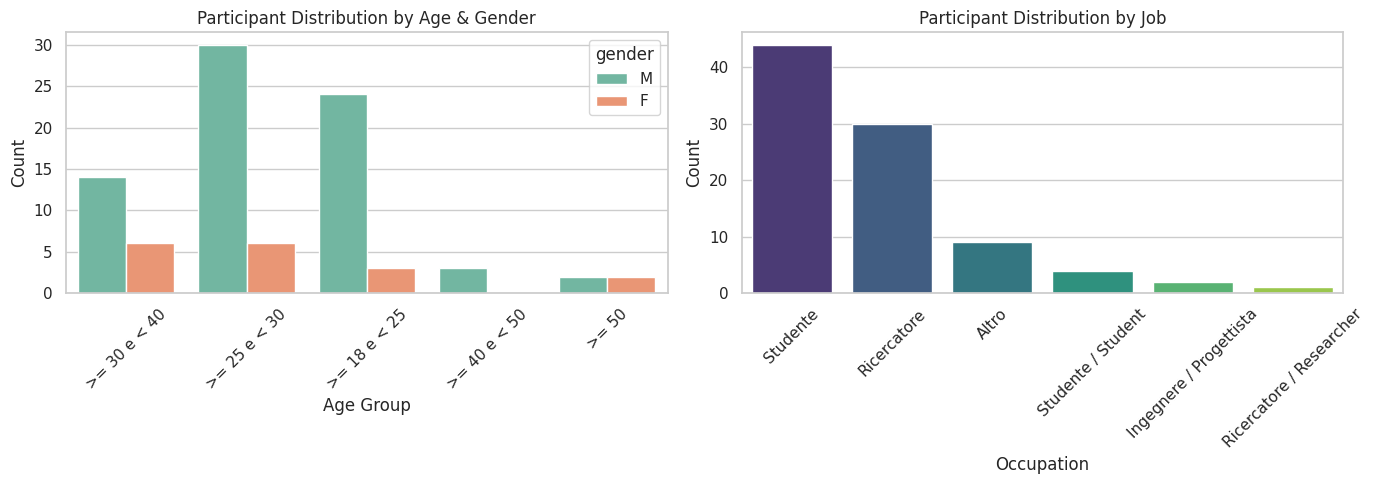

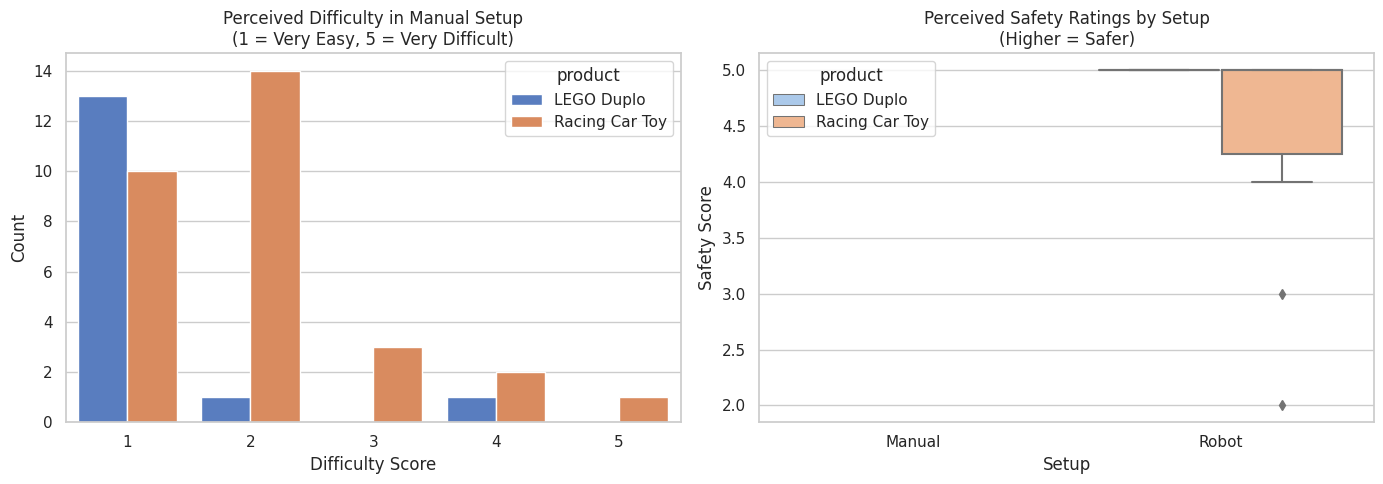

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the data is saved in 'manual.csv' and 'robot.csv'
df_manual = pd.read_csv('data/manual.csv')
df_robot = pd.read_csv('data/robot.csv')

# Add setup labels for comparison
df_manual['setup'] = 'Manual'
df_robot['setup'] = 'Robot'

# Standardize the 'danger' and 'robot_safe' columns into a unified 'safety_rating'
# In both datasets, a higher score (e.g., 5) indicates a safer experience.
df_manual['safety_rating'] = pd.to_numeric(df_manual['danger'], errors='coerce')
df_robot['safety_rating'] = pd.to_numeric(df_robot['robot_safe'], errors='coerce')

# Combine datasets for demographic and general comparisons
df_combined = pd.concat([df_manual, df_robot], ignore_index=True)

# ---------------------------------------------------------
# 1. Distribution of Setups
# ---------------------------------------------------------
setup_dist = df_combined.groupby(['setup', 'product']).size().unstack(fill_value=0)
print("Participant counts per setup:")
print(setup_dist)
print("\n")

# ---------------------------------------------------------
# 2. Plotting Participant Demographics
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age and Gender Distribution
sns.countplot(data=df_combined, x='age', hue='gender', ax=axes[0], palette='Set2')
axes[0].set_title('Participant Distribution by Age & Gender')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Job Distribution
sns.countplot(data=df_combined, x='job', ax=axes[1], palette='viridis', order=df_combined['job'].value_counts().index)
axes[1].set_title('Participant Distribution by Job')
axes[1].set_xlabel('Occupation')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Plotting Difficulty and Safety Metrics
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Perceived Difficulty (Manual Setup only, as Robot setup uses different metrics)
sns.countplot(data=df_manual, x='perceived_difficulty', hue='product', ax=axes[0], palette='muted')
axes[0].set_title('Perceived Difficulty in Manual Setup\n(1 = Very Easy, 5 = Very Difficult)')
axes[0].set_xlabel('Difficulty Score')
axes[0].set_ylabel('Count')

# Perceived Safety Comparison (Manual vs Robot)
sns.boxplot(data=df_combined, x='setup', y='safety_rating', hue='product', ax=axes[1], palette='pastel')
axes[1].set_title('Perceived Safety Ratings by Setup\n(Higher = Safer)')
axes[1].set_xlabel('Setup')
axes[1].set_ylabel('Safety Score')

plt.tight_layout()
plt.show()